# Import Necessery Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Better looking plots
plt.style.use('seaborn-v0_8')

pd.set_option('display.float_format', '{:.2f}'.format)

print("Import Successfull")

Import Successfull


# Import Dataframe and Inspect

In [24]:
df = pd.read_csv("house_price_dataset.csv")

print("Shape", df.shape)

print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
print("\nMissing Values")
print(df.isna().sum())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

display(df.head())
print("\nDescriptive statistics – numeric columns:")
display(df.describe())

Shape (1000, 18)
Columns (18):
['house_id', 'sqft', 'bedrooms', 'bathrooms', 'age_years', 'lot_size_sqft', 'floors', 'basement_sqft', 'garage_spaces', 'renovation_year', 'dist_to_school_km', 'crime_rate_index', 'energy_rating', 'neighborhood', 'house_type', 'garage', 'pool', 'house_price_usd']

Missing Values
house_id             0
sqft                 0
bedrooms             0
bathrooms            0
age_years            0
lot_size_sqft        0
floors               0
basement_sqft        0
garage_spaces        0
renovation_year      0
dist_to_school_km    0
crime_rate_index     0
energy_rating        0
neighborhood         0
house_type           0
garage               0
pool                 0
house_price_usd      0
dtype: int64

Data types:


,dtype
house_id,object
sqft,int64
bedrooms,int64
bathrooms,int64
age_years,int64
lot_size_sqft,int64
floors,int64
basement_sqft,int64
garage_spaces,int64
renovation_year,int64


,house_id,sqft,bedrooms,bathrooms,age_years,lot_size_sqft,floors,basement_sqft,garage_spaces,renovation_year,dist_to_school_km,crime_rate_index,energy_rating,neighborhood,house_type,garage,pool,house_price_usd
0,H0001,1312,1,3,31,7814,1,61,0,0,7.68,1.20,B,Suburbs,Apartment,0,1,90824.72
1,H0002,3836,2,4,75,9615,3,318,1,2001,1.71,4.40,C,Downtown,Townhouse,1,1,330252.33
2,H0003,3217,5,3,5,15554,3,1287,4,2003,8.74,7.30,A,Historic,Apartment,1,0,335007.49
3,H0004,1053,7,2,12,12955,3,727,1,2024,14.06,6.80,E,Rural,Semi-Detached,1,0,96979.23
4,H0005,1801,5,2,20,15647,1,469,0,2005,4.16,2.90,E,Waterfront,Detached,0,1,387807.85



Descriptive statistics – numeric columns:


,sqft,bedrooms,bathrooms,age_years,lot_size_sqft,floors,basement_sqft,garage_spaces,renovation_year,dist_to_school_km,crime_rate_index,garage,pool,house_price_usd
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2664.81,3.90,2.98,40.40,9882.79,2.58,769.14,1.98,1421.97,7.21,5.57,0.50,0.51,276637.93
std,1326.29,1.98,1.43,23.42,5532.37,1.11,433.98,1.43,909.31,4.28,2.61,0.50,0.50,124759.67
min,400.00,1.00,1.00,0.00,508.00,1.00,2.00,0.00,0.00,0.20,1.00,0.00,0.00,42398.39
25%,1462.25,2.00,2.00,20.00,5082.25,2.00,393.75,1.00,0.00,3.38,3.20,0.00,0.00,184020.43
50%,2671.00,4.00,3.00,40.00,9748.50,3.00,774.50,2.00,1993.00,7.00,5.70,0.00,1.00,257596.12
75%,3801.75,6.00,4.00,61.00,14765.50,4.00,1153.00,3.00,2010.00,10.91,7.80,1.00,1.00,352269.29
max,4979.00,7.00,5.00,80.00,19998.00,4.00,1499.00,4.00,2024.00,14.97,10.00,1.00,1.00,720831.66


# Quick look at target distribution

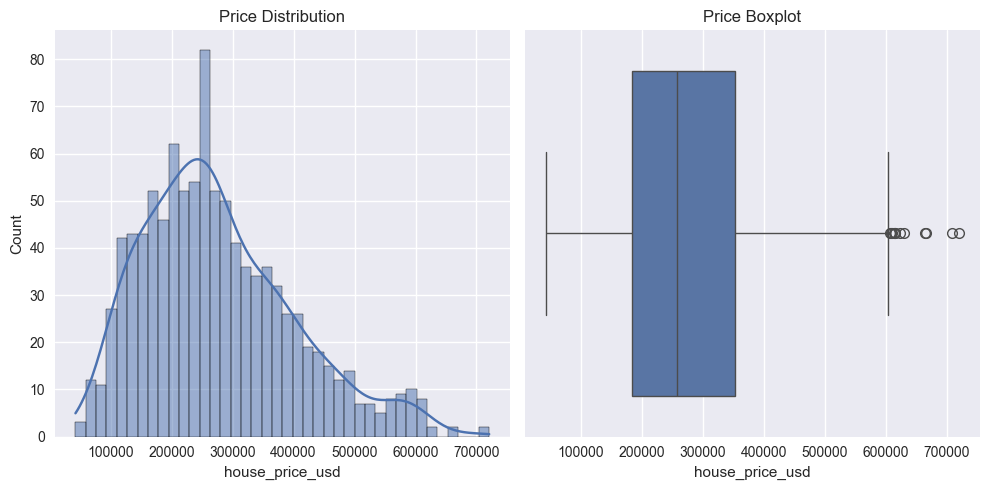

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['house_price_usd'], bins = 40, kde=True)
plt.title("Price Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df['house_price_usd'])
plt.title("Price Boxplot")

plt.tight_layout()
plt.show()

# Detect outliers (using IQR method) for all numeric columns

In [26]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns: {numeric_cols}\n")

# Function to find outliers using IQR
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

# Dictionary to store results
outlier_summary = {}

print("Outlier detection using IQR method (1.5 × IQR):\n" + "-"*60)

for col in numeric_cols:
    outliers, lb, ub = find_outliers_iqr(df, col)
    outlier_summary[col] = {
        'count': len(outliers),
        'percentage': len(outliers)/len(df)*100,
        'min_outlier': outliers.min() if not outliers.empty else np.nan,
        'max_outlier': outliers.max() if not outliers.empty else np.nan,
        'lower_bound': lb,
        'upper_bound': ub
    }
    
    if len(outliers) > 0:
        print(f"{col:20} → {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.2f}%)")
        print(f"   Range: [{lb:.2f}, {ub:.2f}]")
        print(f"   Extreme values: min={outliers.min():.2f}, max={outliers.max():.2f}")
        print()

# Summary table
summary_df = pd.DataFrame(outlier_summary).T
summary_df = summary_df.round(2)
print("\nOutlier Summary Table:")
display(summary_df)

Numeric columns: ['sqft', 'bedrooms', 'bathrooms', 'age_years', 'lot_size_sqft', 'floors', 'basement_sqft', 'garage_spaces', 'renovation_year', 'dist_to_school_km', 'crime_rate_index', 'garage', 'pool', 'house_price_usd']

Outlier detection using IQR method (1.5 × IQR):
------------------------------------------------------------
house_price_usd      →  12 outliers (1.20%)
   Range: [-68352.84, 604642.56]
   Extreme values: min=606878.74, max=720831.66


Outlier Summary Table:


,count,percentage,min_outlier,max_outlier,lower_bound,upper_bound
sqft,0.00,0.00,NaN,NaN,-2047.00,7311.00
bedrooms,0.00,0.00,NaN,NaN,-4.00,12.00
bathrooms,0.00,0.00,NaN,NaN,-1.00,7.00
age_years,0.00,0.00,NaN,NaN,-41.50,122.50
lot_size_sqft,0.00,0.00,NaN,NaN,-9442.62,29290.38
floors,0.00,0.00,NaN,NaN,-1.00,7.00
basement_sqft,0.00,0.00,NaN,NaN,-745.12,2291.88
garage_spaces,0.00,0.00,NaN,NaN,-2.00,6.00
renovation_year,0.00,0.00,NaN,NaN,-3015.00,5025.00
dist_to_school_km,0.00,0.00,NaN,NaN,-7.92,22.21


# Visualize outliers (boxplots for all numeric columns)

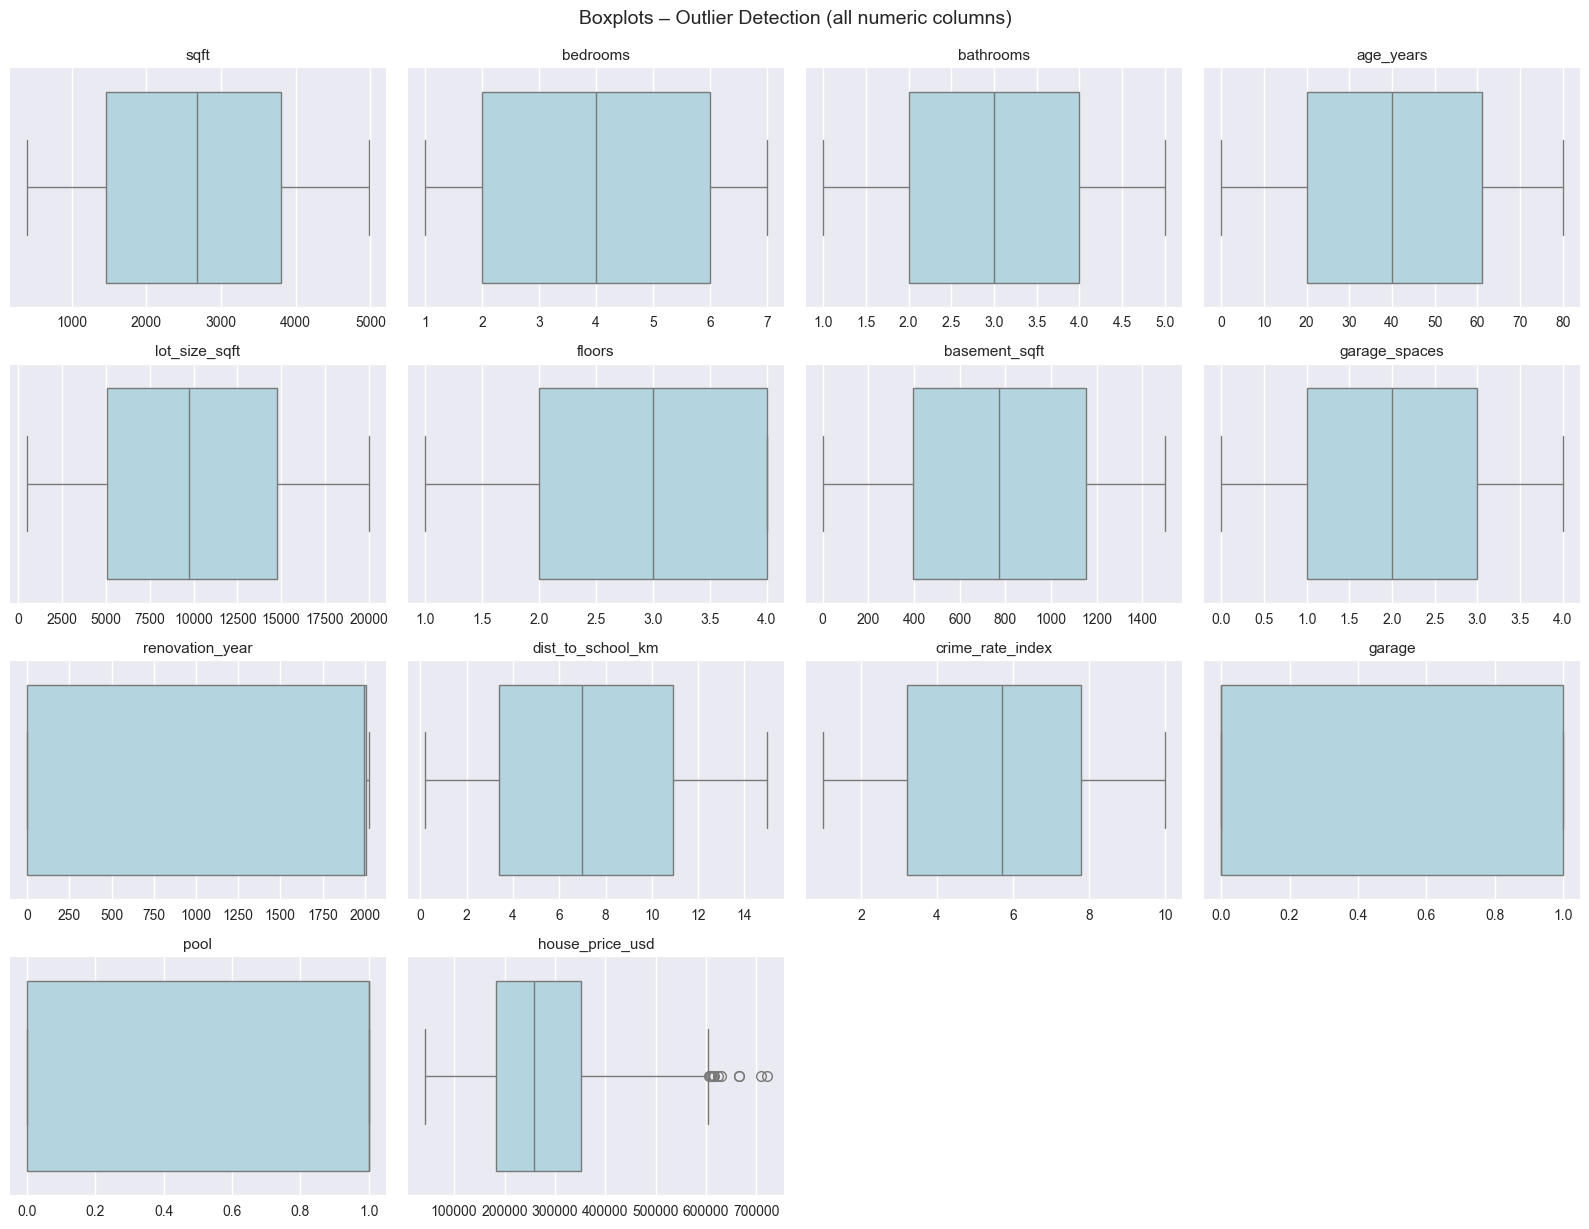

In [28]:
# Create boxplots for all numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4   # adjust layout

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(col, fontsize=11)
    plt.xlabel("")

plt.tight_layout()
plt.suptitle("Boxplots – Outlier Detection (all numeric columns)", y=1.02, fontsize=14)
plt.show()

# Cap outliers (winsorization)

In [29]:
# Option B: Cap (winsorize) outliers instead of removing rows
# → values below lower bound → lower bound
# → values above upper bound → upper bound

df_capped = df.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Cap the values
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print("Outliers have been capped (winsorized).")
print("Original vs capped summary for house_price_usd:")
print(pd.concat([
    df['house_price_usd'].describe(),
    df_capped['house_price_usd'].describe()
], axis=1, keys=['Original', 'Capped']).round(0))

Outliers have been capped (winsorized).
Original vs capped summary for house_price_usd:
       Original    Capped
count   1000.00   1000.00
mean  276638.00 276209.00
std   124760.00 123492.00
min    42398.00  42398.00
25%   184020.00 184020.00
50%   257596.00 257596.00
75%   352269.00 352269.00
max   720832.00 604643.00


# Compare boxplots before & after capping

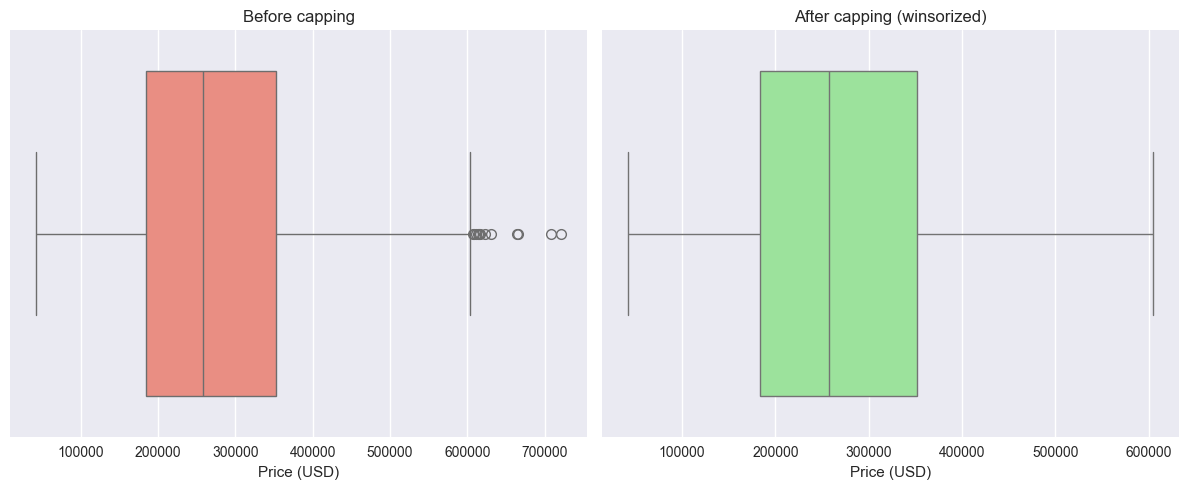

In [30]:
# Visual comparison before vs after capping (only for house_price_usd as example)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['house_price_usd'], color='salmon')
plt.title("Before capping")
plt.xlabel("Price (USD)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_capped['house_price_usd'], color='lightgreen')
plt.title("After capping (winsorized)")
plt.xlabel("Price (USD)")

plt.tight_layout()
plt.show()

# Prepare features and target

In [31]:
x = df.drop(['house_price_usd', 'house_id'], axis = 1)
y = df['house_price_usd']

print("Features shape:", x.shape)
print("Target shape:  ", y.shape)

Features shape: (1000, 16)
Target shape:   (1000,)


# Define categorical and numerical columns

In [32]:
features = df.drop(columns = ['house_price_usd', 'house_id'], axis = 1)

numeric_features = features.select_dtypes(['number', 'int64', 'float']).columns.tolist()
categorical_features = features.select_dtypes(['category', 'object']).columns.tolist()

print("Numeric Features: ", numeric_features)
print("Categorical Features: ", categorical_features)

Numeric Features:  ['sqft', 'bedrooms', 'bathrooms', 'age_years', 'lot_size_sqft', 'floors', 'basement_sqft', 'garage_spaces', 'renovation_year', 'dist_to_school_km', 'crime_rate_index', 'garage', 'pool']
Categorical Features:  ['energy_rating', 'neighborhood', 'house_type']


# Create preprocessor + polynomial pipeline

In [33]:
deg = 2

# preprocessing process
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop = 'first', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing Done!")

# creating pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=deg, include_bias= False)),
    ('regressor', LinearRegression())
])
model

Preprocessing Done!


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# Train / test split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

print(f"Train set: {x_train.shape[0]:4d} rows  ({len(x_train)/len(x)*100:.1f}%)")
print(f"Test set : {x_test.shape[0]:4d} rows  ({len(x_test)/len(x)*100:.1f}%)")

Train set:  800 rows  (80.0%)
Test set :  200 rows  (20.0%)


# Train the model

In [35]:
model.fit(x_train, y_train)

print("Model Trained")

Model Trained


# Predictions & evaluation function

In [36]:
y_pred_train = model.predict(x_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("┌────────────────────── TRAIN ──────────────────────┐")
print(f"│ MAE  = {mae_train:10.3f}                                 │")
print(f"│ RMSE = {rmse_train:10.3f}                                 │")
print(f"│ R²   = {r2_train:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

y_pred_test = model.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("┌────────────────────── TEST ───────────────────────┐")
print(f"│ MAE  = {mae_test:10.3f}                                 │")
print(f"│ RMSE = {rmse_test:10.3f}                                 │")
print(f"│ R²   = {r2_test:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

┌────────────────────── TRAIN ──────────────────────┐
│ MAE  =   9999.354                                 │
│ RMSE =  12627.448                                 │
│ R²   =      0.990                                 │
└───────────────────────────────────────────────────┘
┌────────────────────── TEST ───────────────────────┐
│ MAE  =  15676.183                                 │
│ RMSE =  20154.165                                 │
│ R²   =      0.975                                 │
└───────────────────────────────────────────────────┘


# Visual comparison (actual vs predicted)

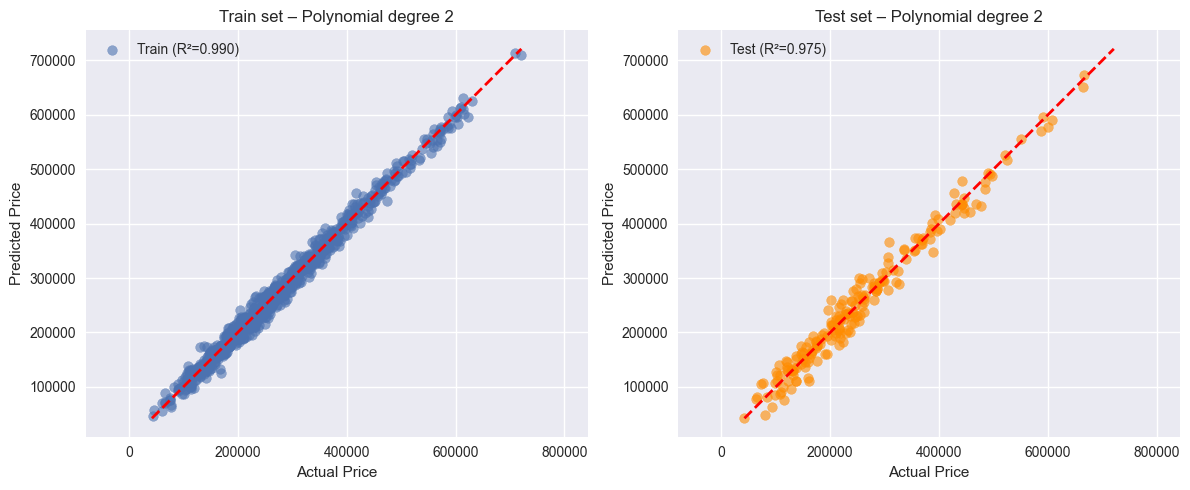

In [37]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train, alpha=0.6, 
            label=f'Train (R²={r2_score(y_train, y_pred_train):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Train set – Polynomial degree {deg}")
plt.legend()
plt.axis('equal')

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkorange', 
            label=f'Test (R²={r2_score(y_test, y_pred_test):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Test set – Polynomial degree {deg}")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# COMPARE POLYNOMIAL DEGREES (1–4)

In [38]:
results = []

for deg in [1, 2, 3, 4]: 
    model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=deg, include_bias= False)),
    ('regressor', LinearRegression())
])
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    results.append({
        'degree':     deg,
        'R² train':   r2_score(y_train, y_pred_train),
        'R² test':    r2_score(y_test,  y_pred_test),
        'R² diff':    r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
        'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE test':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'RMSE diff':  np.sqrt(mean_squared_error(y_train, y_pred_train)) - 
                      np.sqrt(mean_squared_error(y_test,  y_pred_test))
    })

df_results = pd.DataFrame(results).round(4)
df_results
# #Styled output
# styled = df_results.style\
#     .background_gradient(subset=['R² test'], cmap='RdYlGn')\
#     .background_gradient(subset=['RMSE test'], cmap='YlOrRd_r')\
#     .format({
#         'R² train':   '{:.4f}',
#         'R² test':    '{:.4f}',
#         'R² diff':    '{:+.4f}',
#         'RMSE train': '{:,.0f}',
#         'RMSE test':  '{:,.0f}',
#         'RMSE diff':  '{:+.0f}'
#     })\
#     .highlight_max(subset=['R² test'], color='#dedda')\
#     .highlight_min(subset=['RMSE test'], color='#dedda')

# print("Model comparison across polynomial degrees:")
# display(styled)

,degree,R² train,R² test,R² diff,RMSE train,RMSE test,RMSE diff
0,1,0.93,0.92,0.01,31607.21,35221.82,-3614.61
1,2,0.99,0.97,0.01,12627.45,20154.17,-7526.72
2,3,1.00,0.84,0.16,0.00,50835.00,-50835.00
3,4,1.00,0.79,0.21,0.00,57790.57,-57790.57


# FINAL MODEL WITH BEST DEGREE + VISUALIZATION

Final model (degree 2) performance on test set:
• R²   = 0.9749
• RMSE = $20,154
• MAE  = $15,676



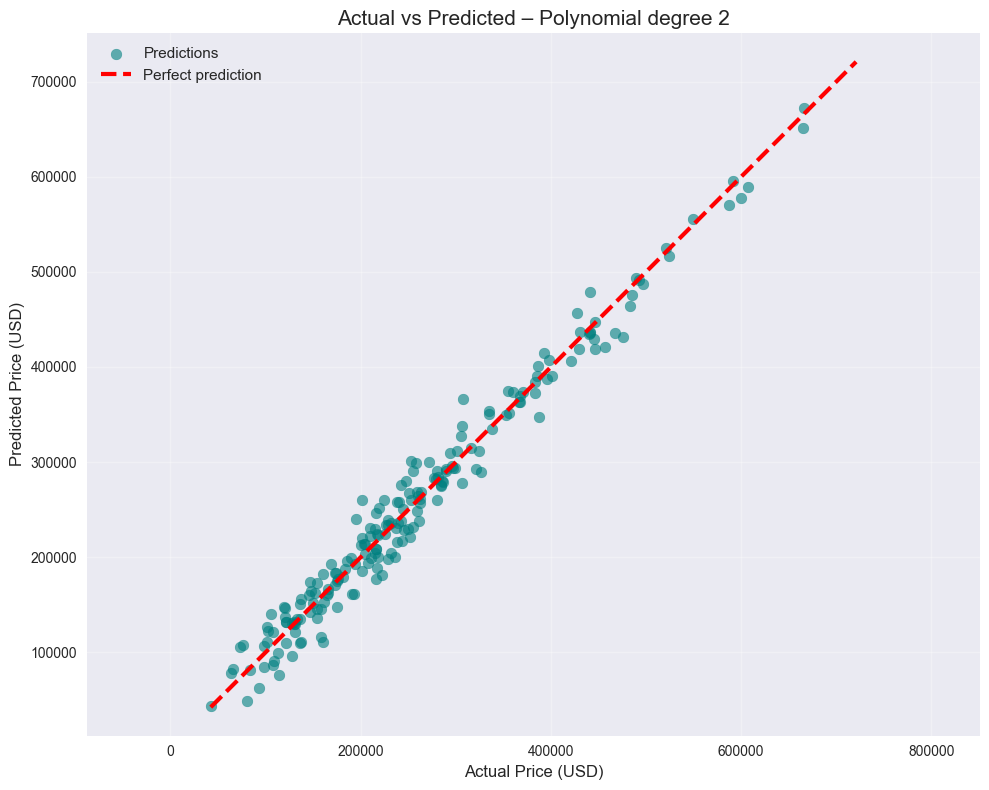

In [39]:
best_degree = df_results.loc[df_results['R² test'].idxmax(), 'degree']

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model',        LinearRegression())
])

final_pipe.fit(x_train, y_train)

y_pred_test = final_pipe.predict(x_test)

mae   = mean_absolute_error(y_test, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2    = r2_score(y_test, y_pred_test)

print(f"Final model (degree {best_degree}) performance on test set:")
print(f"• R²   = {r2:.4f}")
print(f"• RMSE = ${rmse:,.0f}")
print(f"• MAE  = ${mae:,.0f}\n")

# Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=60, color='teal', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Perfect prediction')
plt.xlabel("Actual Price (USD)", fontsize=12)
plt.ylabel("Predicted Price (USD)", fontsize=12)
plt.title(f"Actual vs Predicted – Polynomial degree {best_degree}", fontsize=15)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# EXAMPLE PREDICTION

In [40]:
example_house = pd.DataFrame([{
    'sqft': 2400,
    'bedrooms': 4,
    'bathrooms': 3,
    'age_years': 7,
    'lot_size_sqft': 8200,
    'floors': 2,
    'basement_sqft': 500,
    'garage_spaces': 2,
    'renovation_year': 2021,
    'dist_to_school_km': 1.8,
    'crime_rate_index': 2.9,
    'energy_rating': 'B',
    'neighborhood': 'Suburbs',
    'house_type': 'Detached',
    'garage': 1,
    'pool': 0
}])

predicted_price = final_pipe.predict(example_house)[0]

print(f"Predicted house price: ${predicted_price:,.0f}")

Predicted house price: $294,418
